# Exploratory Data Analysis (EDA) - Steel Defect Dataset

Este notebook realiza análisis exploratorio del dataset procesado:
- Visualización de muestras de cada categoría
- Análisis de distribución de clases
- Estadísticas de imágenes (dimensiones, valores de píxeles)
- Verificación de calidad del dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import random
from collections import Counter

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed
random.seed(42)
np.random.seed(42)

In [2]:
# Define paths
BASE_DIR = Path(r'C:\Users\hecto\OneDrive\Desktop\Ciencia de Datos')
PROCESSED_DATA_DIR = BASE_DIR / 'data' / 'processed'

# Categories
CATEGORIES = ['pitting_corrosion', 'surface_inclusions', 'cracks_scratches', 'flawless_prime']
CATEGORY_LABELS = {
    'pitting_corrosion': 'Pitting Corrosion',
    'surface_inclusions': 'Surface Inclusions',
    'cracks_scratches': 'Cracks & Scratches',
    'flawless_prime': 'Flawless Prime'
}

print(f"Data directory: {PROCESSED_DATA_DIR}")
print(f"Categories: {CATEGORIES}")

Data directory: C:\Users\hecto\OneDrive\Desktop\Ciencia de Datos\data\processed
Categories: ['pitting_corrosion', 'surface_inclusions', 'cracks_scratches', 'flawless_prime']


## 1. Dataset Distribution Analysis

In [3]:
# Count images per category and split
dataset_stats = {}

for split in ['train', 'val', 'test']:
    split_dir = PROCESSED_DATA_DIR / split
    dataset_stats[split] = {}
    
    for category in CATEGORIES:
        category_dir = split_dir / category
        if category_dir.exists():
            count = len(list(category_dir.glob('*')))
            dataset_stats[split][category] = count

# Display statistics
print("Dataset Distribution:\n")
print(f"{'Category':<25} {'Train':<10} {'Val':<10} {'Test':<10} {'Total':<10}")
print("="*65)

totals = {'train': 0, 'val': 0, 'test': 0}
for category in CATEGORIES:
    train_count = dataset_stats['train'].get(category, 0)
    val_count = dataset_stats['val'].get(category, 0)
    test_count = dataset_stats['test'].get(category, 0)
    total = train_count + val_count + test_count
    
    totals['train'] += train_count
    totals['val'] += val_count
    totals['test'] += test_count
    
    print(f"{CATEGORY_LABELS[category]:<25} {train_count:<10} {val_count:<10} {test_count:<10} {total:<10}")

print("="*65)
grand_total = totals['train'] + totals['val'] + totals['test']
print(f"{'TOTAL':<25} {totals['train']:<10} {totals['val']:<10} {totals['test']:<10} {grand_total:<10}")
print(f"\nPercentages: Train={totals['train']/grand_total*100:.1f}%, Val={totals['val']/grand_total*100:.1f}%, Test={totals['test']/grand_total*100:.1f}%")

Dataset Distribution:

Category                  Train      Val        Test       Total     
Pitting Corrosion         210        45         45         300       
Surface Inclusions        420        90         90         600       
Cracks & Scratches        420        90         90         600       
Flawless Prime            210        45         45         300       
TOTAL                     1260       270        270        1800      

Percentages: Train=70.0%, Val=15.0%, Test=15.0%


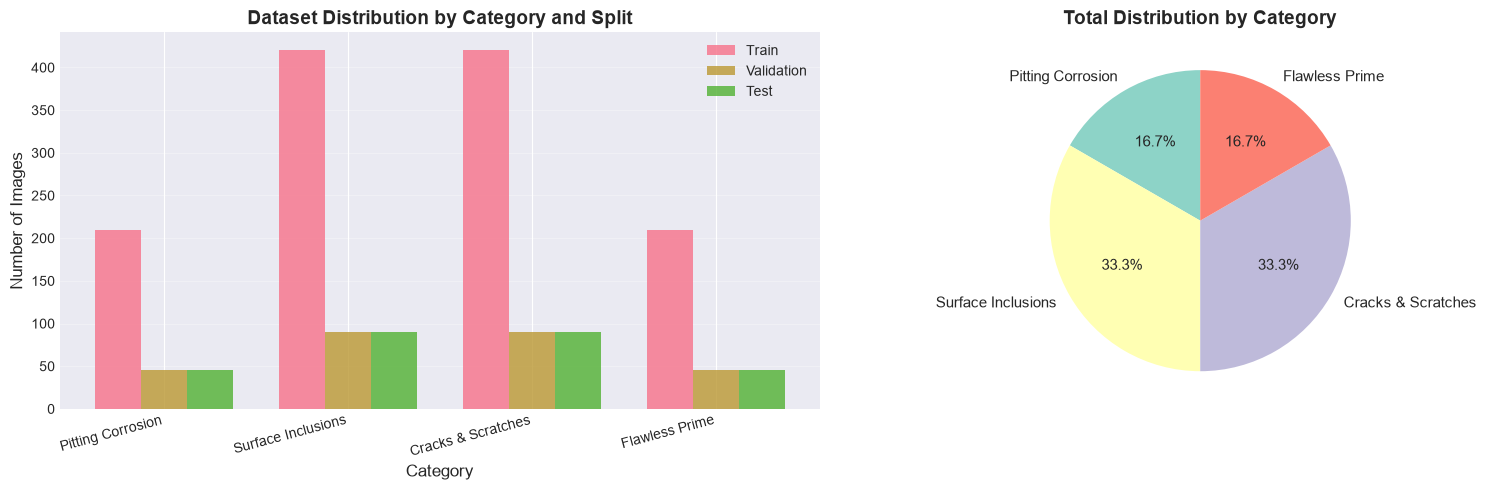


✓ Dataset is imbalanced


In [4]:
# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Distribution by category
categories_labels = [CATEGORY_LABELS[cat] for cat in CATEGORIES]
train_counts = [dataset_stats['train'][cat] for cat in CATEGORIES]
val_counts = [dataset_stats['val'][cat] for cat in CATEGORIES]
test_counts = [dataset_stats['test'][cat] for cat in CATEGORIES]

x = np.arange(len(CATEGORIES))
width = 0.25

axes[0].bar(x - width, train_counts, width, label='Train', alpha=0.8)
axes[0].bar(x, val_counts, width, label='Validation', alpha=0.8)
axes[0].bar(x + width, test_counts, width, label='Test', alpha=0.8)
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Dataset Distribution by Category and Split', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories_labels, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Total distribution pie chart
total_per_category = [train_counts[i] + val_counts[i] + test_counts[i] for i in range(len(CATEGORIES))]
colors = plt.cm.Set3(range(len(CATEGORIES)))
axes[1].pie(total_per_category, labels=categories_labels, autopct='%1.1f%%', 
            startangle=90, colors=colors, textprops={'fontsize': 11})
axes[1].set_title('Total Distribution by Category', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Dataset is {'balanced' if max(total_per_category)/min(total_per_category) < 1.5 else 'imbalanced'}")

## 2. Sample Image Visualization

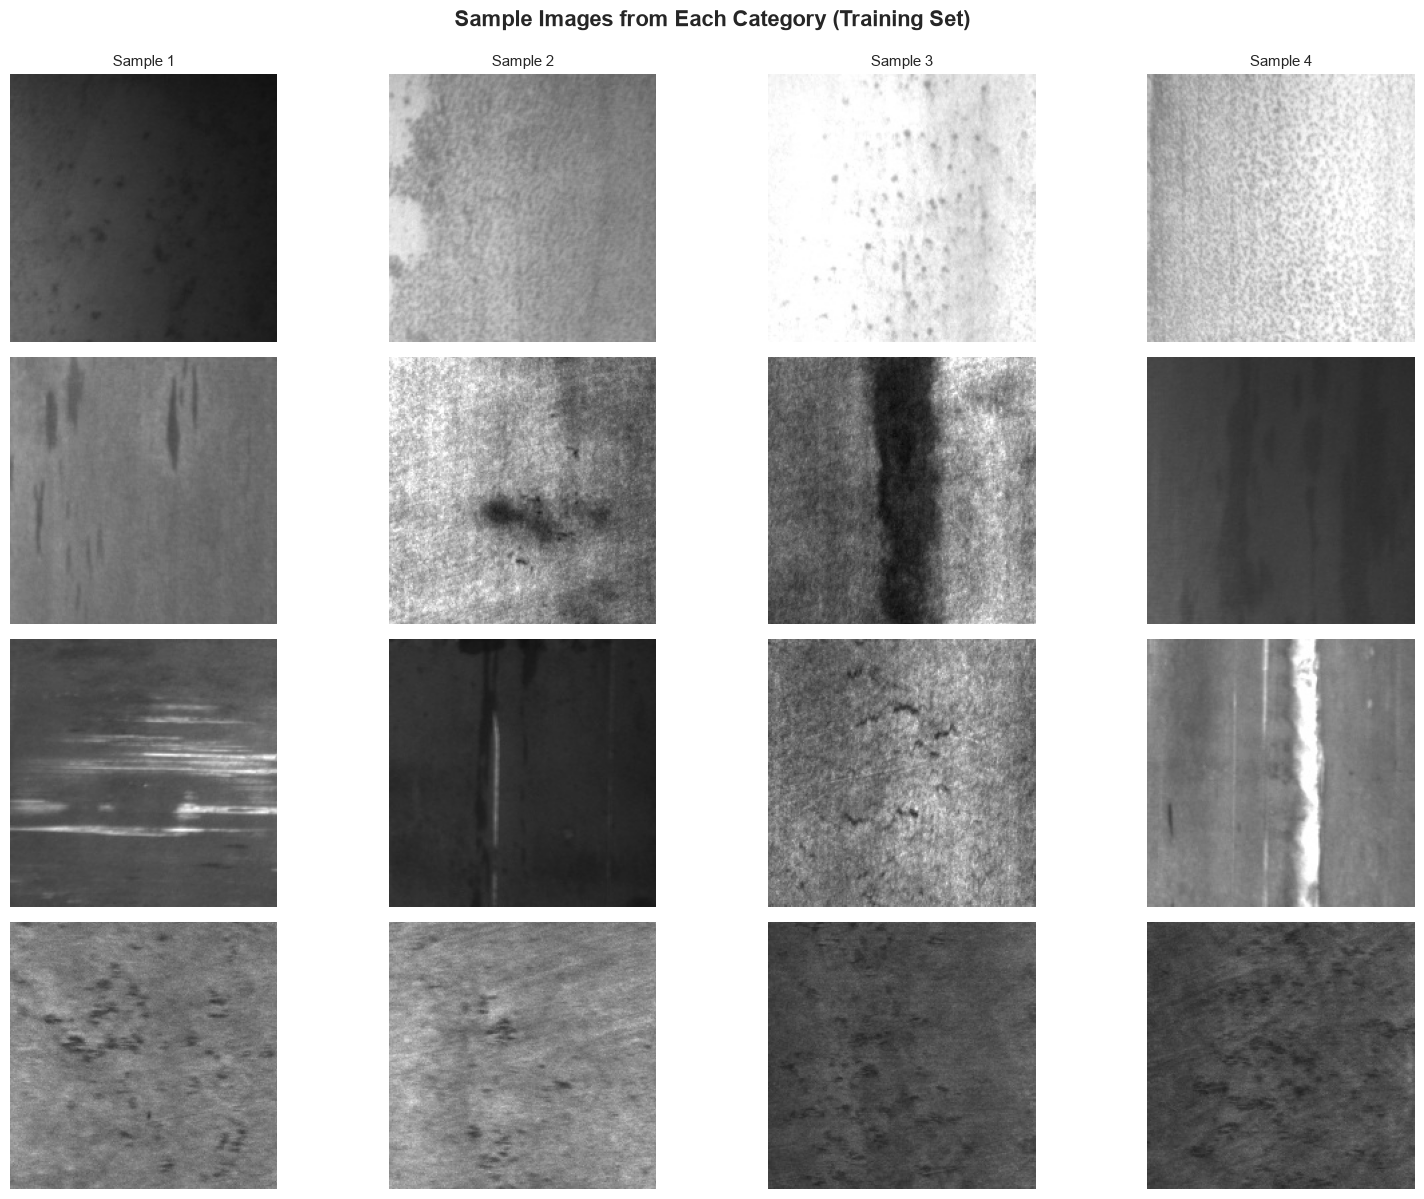

In [5]:
# Display sample images from each category
n_samples = 4
fig, axes = plt.subplots(len(CATEGORIES), n_samples, figsize=(16, 12))

for i, category in enumerate(CATEGORIES):
    category_dir = PROCESSED_DATA_DIR / 'train' / category
    images = list(category_dir.glob('*'))[:n_samples]
    
    for j, img_path in enumerate(images):
        img = Image.open(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        
        if j == 0:
            axes[i, j].set_ylabel(CATEGORY_LABELS[category], fontsize=12, fontweight='bold', rotation=90)
        
        if i == 0:
            axes[i, j].set_title(f'Sample {j+1}', fontsize=11)

fig.suptitle('Sample Images from Each Category (Training Set)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 3. Image Properties Analysis

In [6]:
# Analyze image dimensions and properties
def analyze_images(split='train', sample_size=50):
    dimensions = []
    pixel_stats = []
    
    split_dir = PROCESSED_DATA_DIR / split
    
    for category in CATEGORIES:
        category_dir = split_dir / category
        images = list(category_dir.glob('*'))[:sample_size]
        
        for img_path in images:
            img = Image.open(img_path)
            img_array = np.array(img)
            
            dimensions.append(img.size)  # (width, height)
            pixel_stats.append({
                'mean': img_array.mean(),
                'std': img_array.std(),
                'min': img_array.min(),
                'max': img_array.max()
            })
    
    return dimensions, pixel_stats

print("Analyzing image properties...\n")
dimensions, pixel_stats = analyze_images('train', sample_size=50)

# Dimensions analysis
unique_dims = set(dimensions)
print(f"Unique image dimensions found: {len(unique_dims)}")
for dim in unique_dims:
    count = dimensions.count(dim)
    print(f"  {dim[0]}x{dim[1]}: {count} images ({count/len(dimensions)*100:.1f}%)")

# Pixel statistics
mean_values = [s['mean'] for s in pixel_stats]
std_values = [s['std'] for s in pixel_stats]

print(f"\nPixel Value Statistics (sample of {len(pixel_stats)} images):")
print(f"  Mean: {np.mean(mean_values):.2f} ± {np.std(mean_values):.2f}")
print(f"  Std:  {np.mean(std_values):.2f} ± {np.std(std_values):.2f}")
print(f"  Range: [{min([s['min'] for s in pixel_stats])}, {max([s['max'] for s in pixel_stats])}]")

Analyzing image properties...

Unique image dimensions found: 1
  200x200: 200 images (100.0%)

Pixel Value Statistics (sample of 200 images):
  Mean: 133.23 ± 45.28
  Std:  25.46 ± 13.65
  Range: [0, 255]


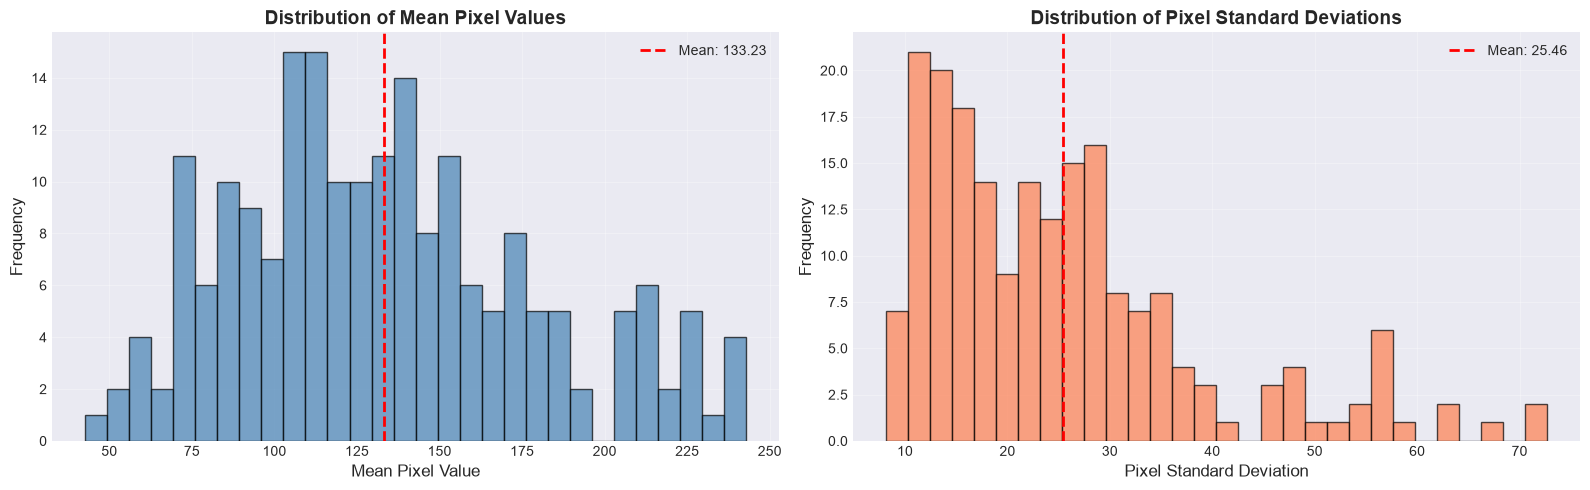

In [7]:
# Visualize pixel distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Mean pixel values distribution
axes[0].hist(mean_values, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(mean_values), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(mean_values):.2f}')
axes[0].set_xlabel('Mean Pixel Value', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Mean Pixel Values', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Standard deviation distribution
axes[1].hist(std_values, bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(np.mean(std_values), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(std_values):.2f}')
axes[1].set_xlabel('Pixel Standard Deviation', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Pixel Standard Deviations', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Intensity Distribution by Category

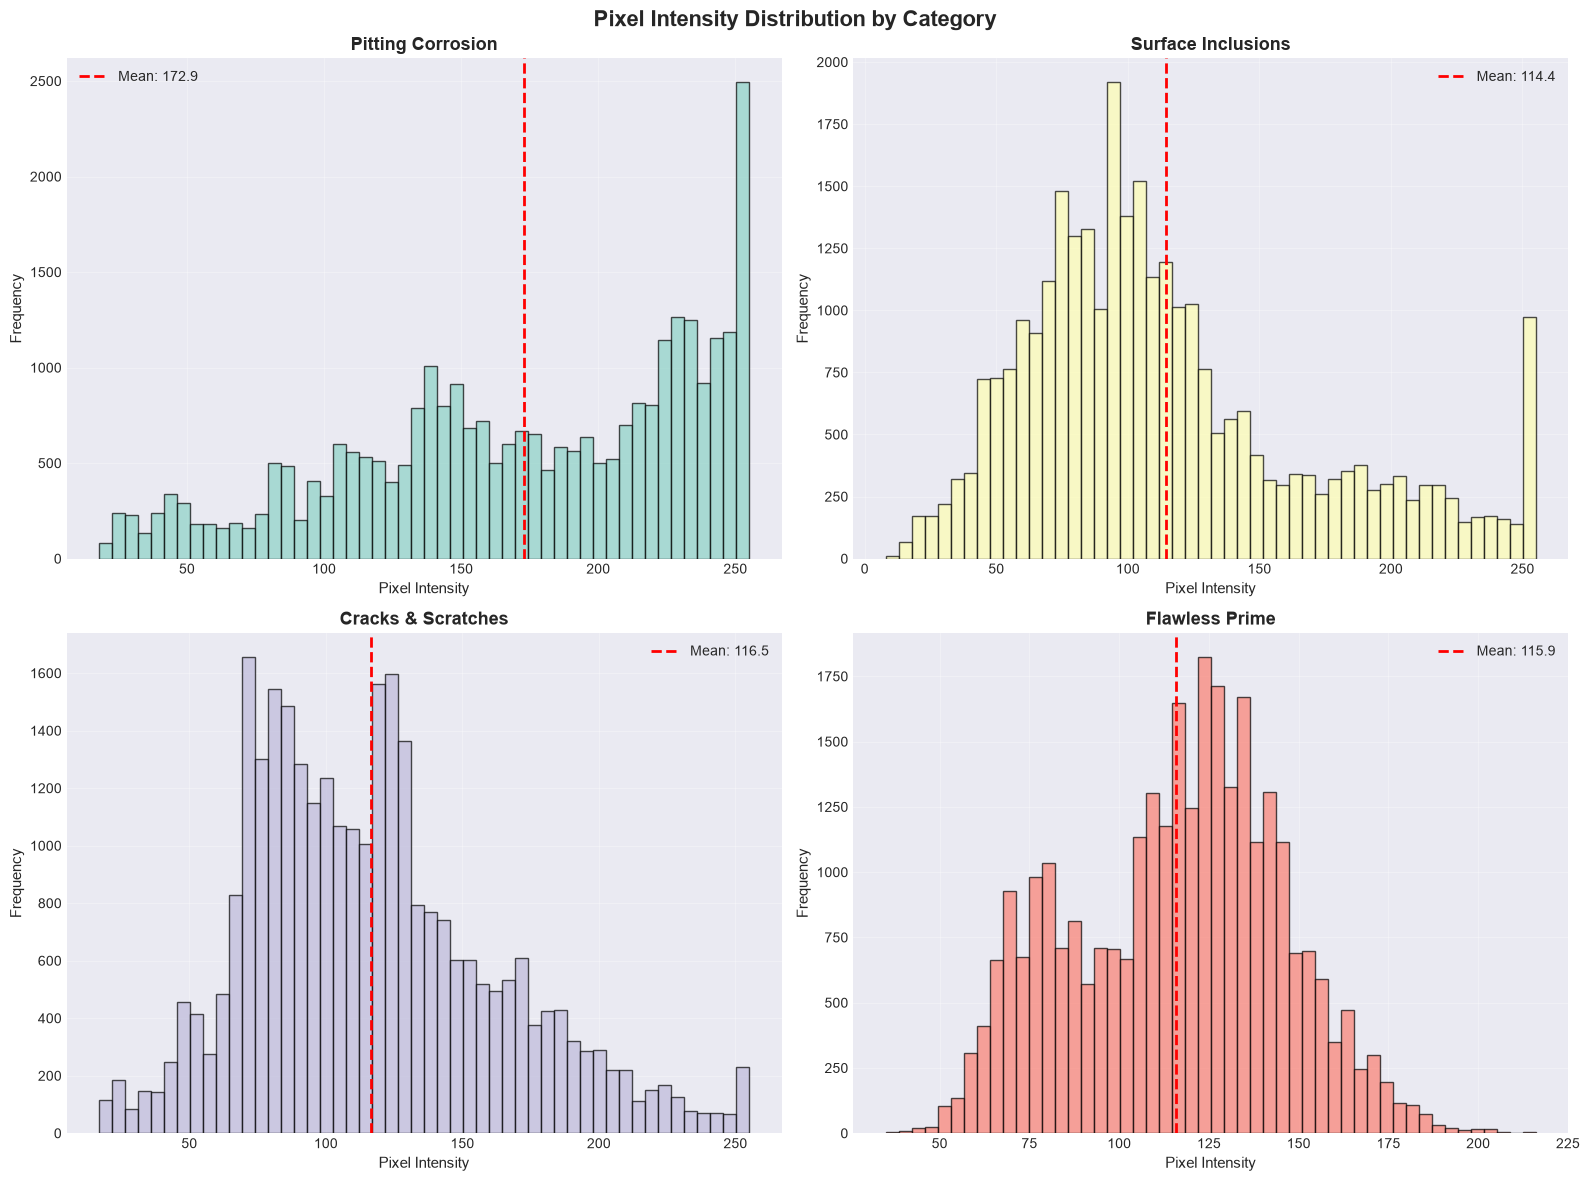

In [8]:
# Analyze pixel intensity distribution per category
category_intensities = {cat: [] for cat in CATEGORIES}

for category in CATEGORIES:
    category_dir = PROCESSED_DATA_DIR / 'train' / category
    images = list(category_dir.glob('*'))[:30]  # Sample 30 images per category
    
    for img_path in images:
        img = Image.open(img_path)
        img_array = np.array(img).flatten()
        category_intensities[category].extend(img_array[:1000])  # Sample 1000 pixels per image

# Plot intensity distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, category in enumerate(CATEGORIES):
    axes[i].hist(category_intensities[category], bins=50, alpha=0.7, color=plt.cm.Set3(i), edgecolor='black')
    axes[i].set_xlabel('Pixel Intensity', fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)
    axes[i].set_title(f'{CATEGORY_LABELS[category]}', fontsize=13, fontweight='bold')
    axes[i].grid(alpha=0.3)
    
    mean_intensity = np.mean(category_intensities[category])
    axes[i].axvline(mean_intensity, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_intensity:.1f}')
    axes[i].legend()

fig.suptitle('Pixel Intensity Distribution by Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Sample Grid Visualization

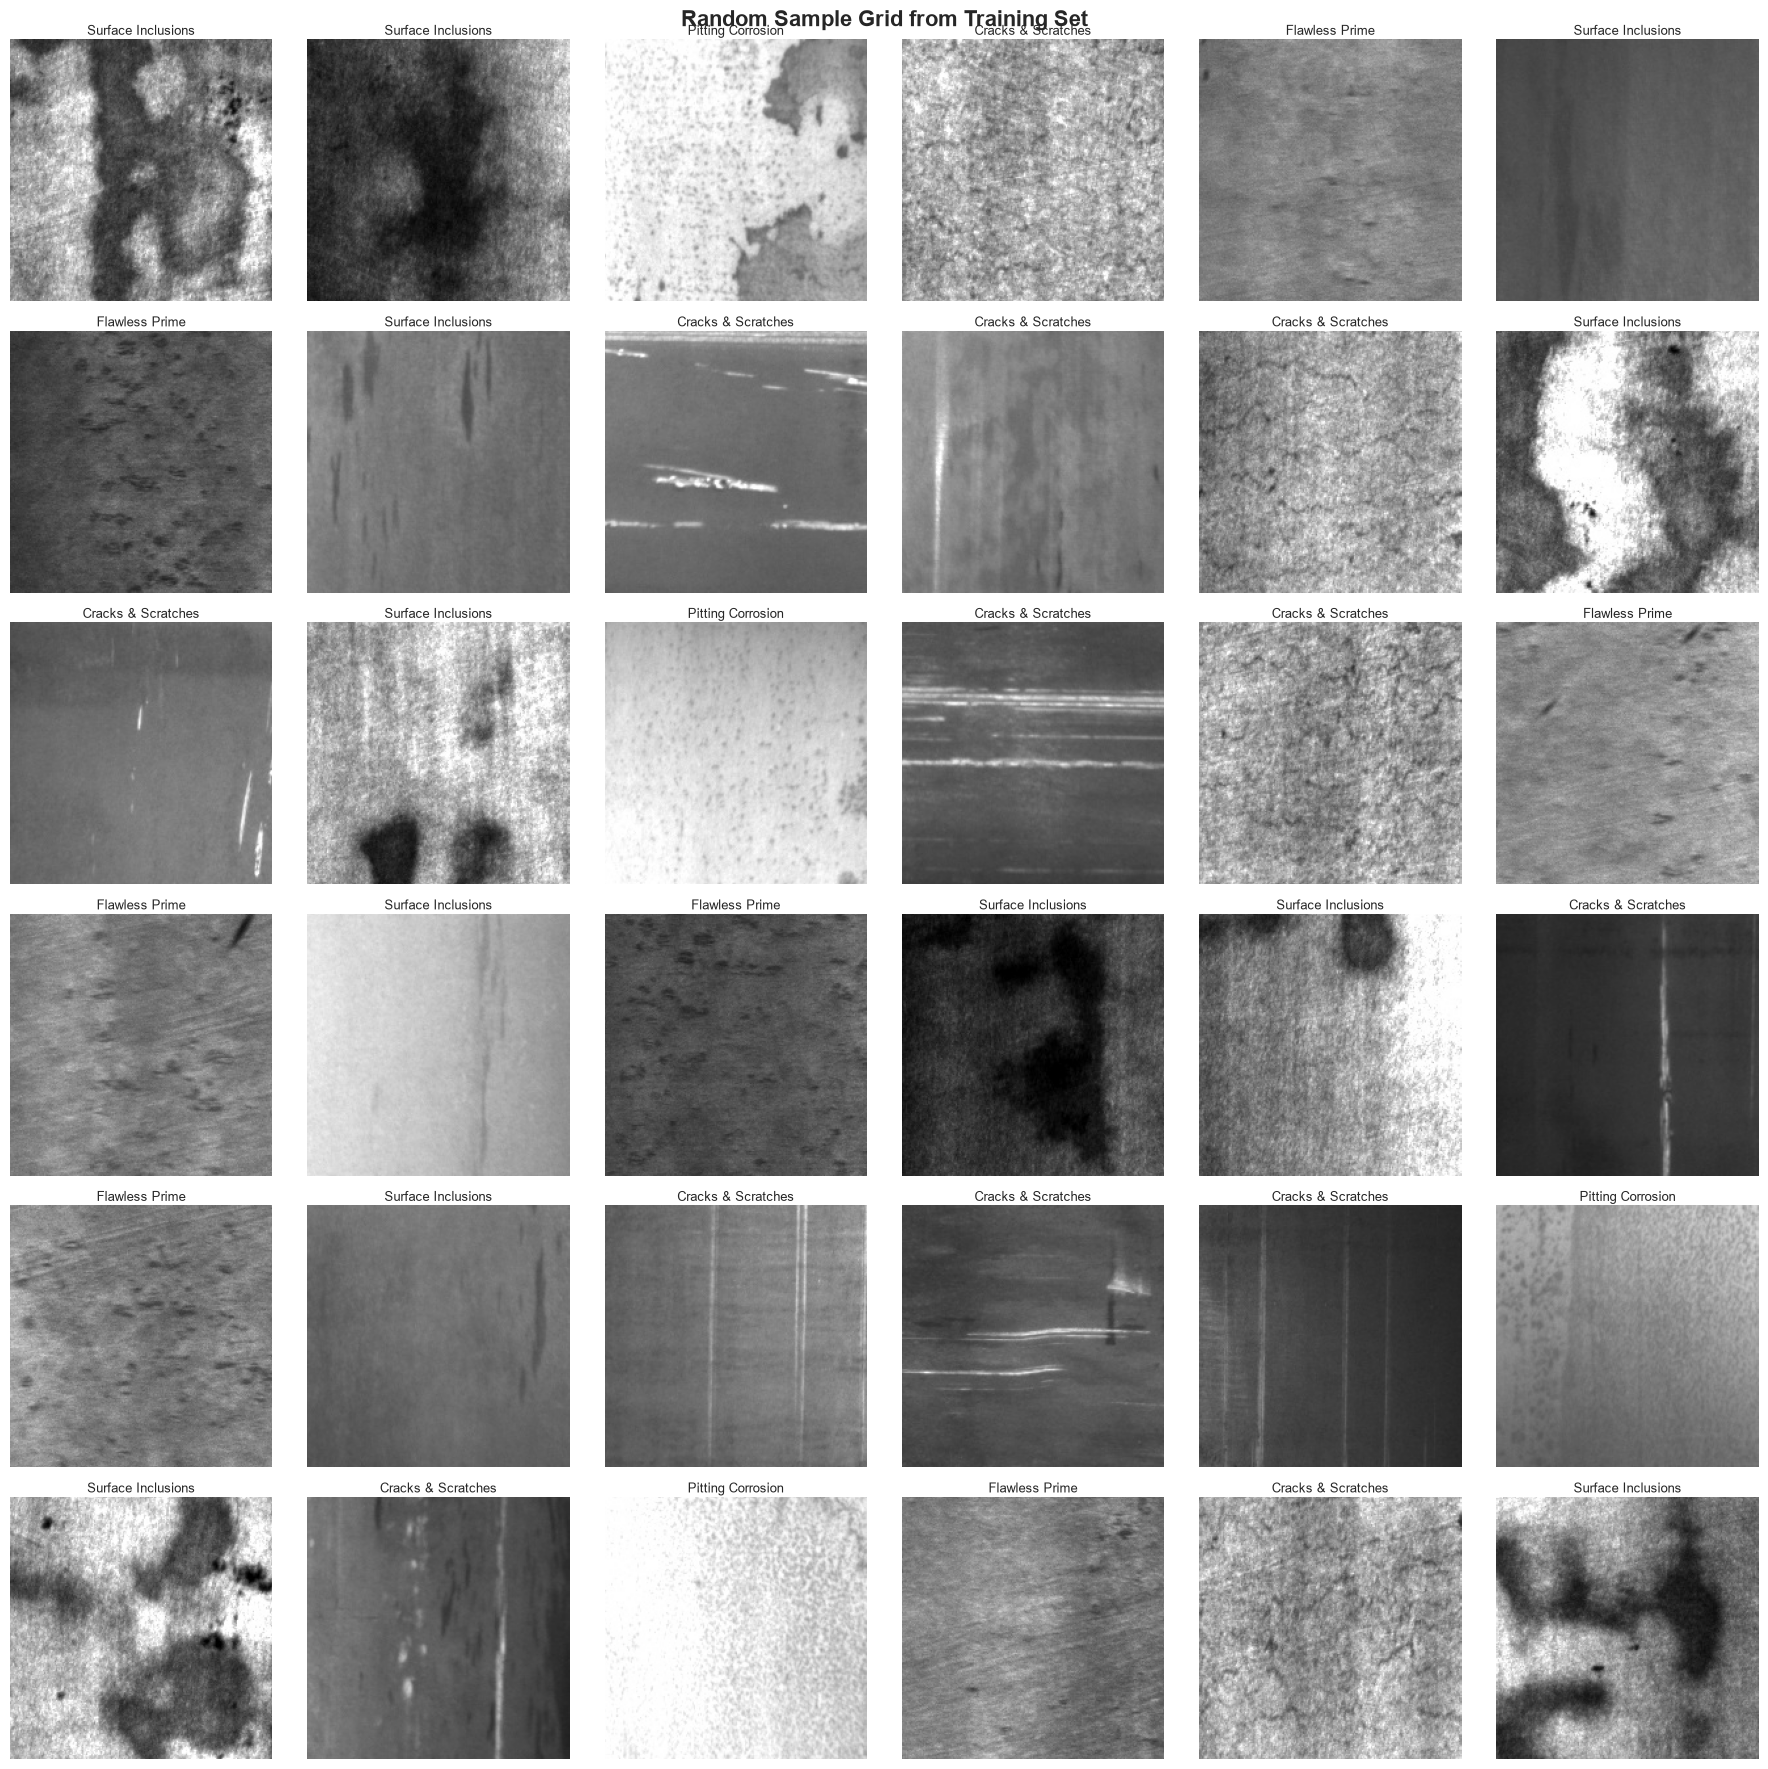

In [9]:
# Create a large grid of random samples
n_rows = 6
n_cols = 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 18))

train_dir = PROCESSED_DATA_DIR / 'train'
all_images = []

for category in CATEGORIES:
    category_dir = train_dir / category
    images = list(category_dir.glob('*'))
    all_images.extend([(img, category) for img in images])

random.shuffle(all_images)
samples = all_images[:n_rows * n_cols]

for idx, (img_path, category) in enumerate(samples):
    i, j = idx // n_cols, idx % n_cols
    
    img = Image.open(img_path)
    axes[i, j].imshow(img, cmap='gray')
    axes[i, j].axis('off')
    axes[i, j].set_title(CATEGORY_LABELS[category], fontsize=9, pad=3)

fig.suptitle('Random Sample Grid from Training Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Summary and Recommendations

In [11]:
print("="*80)
print("EDA SUMMARY AND RECOMMENDATIONS")
print("="*80)

# Calculate class balance
train_counts = [dataset_stats['train'][cat] for cat in CATEGORIES]
imbalance_ratio = max(train_counts) / min(train_counts)

print("\n📊 DATASET CHARACTERISTICS:")
print(f"  • Total images: {grand_total}")
print(f"  • Number of categories: {len(CATEGORIES)}")
print(f"  • Train/Val/Test split: {totals['train']}/{totals['val']}/{totals['test']}")
print(f"  • Class imbalance ratio: {imbalance_ratio:.2f}x")

print("\n🖼️ IMAGE PROPERTIES:")
print(f"  • Dimensions: {list(unique_dims)[0] if len(unique_dims) == 1 else 'Mixed'}")
print(f"  • Pixel range: [0, 255]")
print(f"  • Mean intensity: {np.mean(mean_values):.2f}")
print(f"  • Color space: Grayscale")

print("\n✅ RECOMMENDATIONS FOR MODEL TRAINING:")
print("  1. Normalize pixel values to [0, 1] or standardize to zero mean")
print("  2. Apply data augmentation (rotation, flip, brightness, contrast)")

if imbalance_ratio > 1.5:
    print("  3. ⚠️ Dataset is imbalanced - consider class weights or oversampling")
else:
    print("  3. ✓ Dataset is balanced - standard training approach is suitable")

print("  4. Use transfer learning with pre-trained models (EfficientNet, ResNet, VGG)")
print("  5. Resize images to target size (e.g., 224x224 or 256x256)")
print("  6. Monitor validation performance to prevent overfitting")
print("  7. Use ensemble methods to improve accuracy")

print("\n" + "="*80)
print("✅ EDA Complete! Ready to proceed with model training.")
print("="*80)

EDA SUMMARY AND RECOMMENDATIONS

📊 DATASET CHARACTERISTICS:
  • Total images: 1800
  • Number of categories: 4
  • Train/Val/Test split: 1260/270/270
  • Class imbalance ratio: 2.00x

🖼️ IMAGE PROPERTIES:
  • Dimensions: (200, 200)
  • Pixel range: [0, 255]
  • Mean intensity: 133.23
  • Color space: Grayscale

✅ RECOMMENDATIONS FOR MODEL TRAINING:
  1. Normalize pixel values to [0, 1] or standardize to zero mean
  2. Apply data augmentation (rotation, flip, brightness, contrast)
  3. ⚠️ Dataset is imbalanced - consider class weights or oversampling
  4. Use transfer learning with pre-trained models (EfficientNet, ResNet, VGG)
  5. Resize images to target size (e.g., 224x224 or 256x256)
  6. Monitor validation performance to prevent overfitting
  7. Use ensemble methods to improve accuracy

✅ EDA Complete! Ready to proceed with model training.
